In [169]:
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz, distance
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, RFE
from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
#from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

# Preprocessing

#### Data Quality Assessment and Initial Observations

In [170]:
RANDOM_SEED = 1907
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

##### Let's perform an initial analysis of the train dataset.

In [171]:
df=pd.read_csv("train.csv")
display(df)
og_df = df.copy()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2.000000,0.0


There's a total of 14 columns, with one of them being a candidate to be a unique identifier for each row (**carID**), leaving us 13 features to work with.

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB



Datatypes seem to be A-OK, thus we are left with 4 categorical features:

**Brand, model, transmission and fuelType**

And 10 numeric features:

**cardID, year, price, mileage, tax, mpg, engineSize, paintQuality%, previousOwners and hasDamage**


In [173]:
df.describe()

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


#### Preprocessing **cardID**

Now for us to be able to use **carID** as a true unique identifier we must first make sure there are no duplicates:

In [174]:
df["carID"].duplicated().any()

np.False_

Since there are no duplicates we can now define **carID** as a true unique identifier.

In [175]:
def carID_como_index(df):
    df = df.copy()
    df = df.set_index("carID")
    return df

df=carID_como_index(df)
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


##### Let's assess feature values and counts and see if there's any work to be done here. Let's start with **Brand**

#### Preprocessing **Brand**

In [176]:
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

##### Several values for the same brand although with some missing letters (e.g. 'Audi', 'Aud', 'udi', 'audi', 'AUD' and 'ud' could be considered as all being the same value: AUDI) and some nans.

In [177]:
df["Brand"].value_counts()

Brand
Ford        14808
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
OYOTA           2
SKOD            1
TOYOT           1
skod            1
toyot           1
Name: count, Length: 72, dtype: int64

In [178]:
df[df["Brand"].isna()]


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,T-Roc,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CL Class,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,Golf,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0



~1500 NaNs
To fix incorrect entries, we must define a method to be able to treat these values for **Brand** and have the correct single unique brand name.

To fix the inconsistent and misspelled values for Brand, we’ll define a function that uses fuzzy string matching to map incorrect entries to their correct versions.

The first helper function we’ll define is **HELPER_marca_correta()**, responsible for evaluating each brand value individually and correcting it if necessary. It first checks whether the brand value is valid (i.e., not NaN or empty) and then converts it to lowercase for comparison.

Using fuzzywuzzy **process.extractOne()** (which uses Levenshtein distance or a tokenizer), we compare the given brand to the dictionary of valid brands (**valid_brands**) and returns the closest match, along with a similarity score.

If the similarity score exceeds a defined threshold, the brand value is replaced by the correct brand name. Otherwise, it remains unchanged. The second function, **fuzzy_marcas()**, applies this logic to the entire dataset. It first defines a list of valid brands — in this case: VW, Toyota, Audi, Ford, BMW, Opel, Skoda, Mercedes, and Hyundai.

These are converted into a lowercase dictionary for matching, where each key-value pair ensures the final brand name retains its original capitalization.

Finally, **fuzzy_marcas()** applies **HELPER_marca_correta()** to every value in Brand, replacing incorrect or misspelled records with their correct forms. The **threshold parameter (threshold=50)** controls how strict the matching is. A lower threshold (e.g. 50) allows more aggressive corrections, while a higher one (e.g. 80) ensures only very similar strings are replaced.

This process effectively normalizes **Brand**, e.g. consolidating entries such as 'Audi', 'Aud', 'udi', 'audi', 'AUD' and 'ud' into their correct standardized name, 'Audi'.


In [179]:
def HELPER_marca_correta(marca, marcas_dict, threshold):
    if not isinstance(marca, str) or marca.strip() == "":
        return marca

    marca_lower = marca.lower().strip()

    result = process.extractOne(
        marca_lower,
        marcas_dict.keys(),
        scorer=fuzz.token_sort_ratio
    )
    
    #result = (match, score, index)
    #ex: match = toyota, score = 94.5, index = 1 (qual das marcas no dicionário é mais semelhante)

    if result is None:
        return marca

    match_lower, score, _ = result
    return marcas_dict[match_lower] if score >= threshold else marca

def fuzzy_marcas(df, threshold=50):
    df=df.copy()

    valid_brands = ["VW", "Toyota", "Audi", "Ford", "BMW", "Opel", "Skoda", "Mercedes", "Hyundai"]
    brands_dict = {BRAND.lower(): BRAND for BRAND in valid_brands}

    df["Brand"] = df["Brand"].apply(lambda x: HELPER_marca_correta(x, brands_dict, threshold))
    return df

In [180]:
df=fuzzy_marcas(df)
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'Hyundai', nan], dtype=object)

Thus, the treatment via **HELPER_marca_correta()** was successfull, and we are now left with 9 true brand names and NaN's.

In [181]:
df["Brand"].value_counts()

Brand
Ford        16063
Mercedes    11674
VW          10385
Opel         9352
BMW          7392
Audi         7325
Toyota       4622
Skoda        4303
Hyundai      3336
Name: count, dtype: int64

Let's now move onto **model**.

In [182]:
df["model"].unique()

array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

In [183]:
len(df["model"].unique())

736

In [184]:
# group models by brand
grouped = df.groupby("Brand")["model"].value_counts()

display(grouped["Hyundai"])

model
 Tucson      821
 I10         671
 I30         352
 I20         307
 Kona        213
 Ioniq       185
 Santa Fe    135
 IX20        129
 I40          78
 IX35         74
 I800         72
 i10          20
 Tucso        18
 TUCSON       17
 tucson       16
 I1           15
Tucson        15
I10           13
 I3            9
 Santa F       8
 i30           8
 Ioni          7
 i20           7
 Getz          6
Ioniq          6
Kona           6
I20            5
I30            5
 I2            4
 SANTA FE      4
 I80           3
 IX2           3
 ix20          3
 kona          3
 santa fe      3
Santa Fe       3
 IONIQ         2
 KONA          2
 Kon           2
 ix35          2
IX20           2
IX35           2
 Accent        1
 KON           1
 TUCSO         1
 Terracan      1
 Veloste       1
 i40           1
 ioniq         1
I40            1
IONIQ          1
Tucso          1
Name: count, dtype: int64

In [185]:
#we obtained all the correct model names by feeding all possible variations for each brand into ChatGPT and creating a dictionary with the correct model names
from valid_models import valid_models

We are now left with a dictionary with valid brand names and their corresponding valid model names. Let's perform a similar treatment to the one applied to **Brand** to standardize entries for **model**.

In [186]:
def HELPER_normalize_models(df):
    df = df.copy()
    
    df["model"] = (
        df["model"]
        .astype(str)
        .str.upper()
        .str.replace("-", "", regex=False)       # remove hyphens
        .str.replace(r"\s+", "", regex=True)     # remove all whitespace
        .replace(["", "NAN", "NONE"], None)
    )
    return df

def HELPER_hybrid_scorer(a, b, **kwargs):
    #hibrido entre o método tokenizer e o levenshtein 
    lev = distance.Levenshtein.normalized_similarity(a, b)
    token = fuzz.token_sort_ratio(a, b) / 100
    return (0.7 * lev + 0.3 * token) * 100

def HELPER_modelo_correto(model, brand, valid_models_dict, threshold):
    if not model or model.strip() == "":
        return None

    if not brand:
        return model
    
    # Skip unknown brands
    if brand not in valid_models_dict:
        return model
    
    valid_list = valid_models_dict[brand]

    result = process.extractOne(model, valid_list, scorer=HELPER_hybrid_scorer)

    if result is None:
        return model    

    model_name, score, _ = result
    return model_name if score >= threshold else None

def fuzzy_modelos(df, valid_models_dict, threshold=30):
    df = HELPER_normalize_models(df)
    
    df["model"] = df.apply(
        lambda row: HELPER_modelo_correto(row["model"], row["Brand"], valid_models_dict, threshold),
        axis=1
    )
    return df

In [187]:
len(df["model"].unique())
df[df["model"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,NaN,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,NaN,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,NaN,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,NaN,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,NaN,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,NaN,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,NaN,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [188]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi         62
BMW          91
Ford         92
Hyundai      52
Mercedes    103
Opel         90
Skoda        61
Toyota       68
VW          114
Name: model, dtype: int64


In [189]:
df=fuzzy_modelos(df, valid_models)
display(df[df["model"].isna()])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [190]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi        25
BMW         24
Ford        22
Hyundai     15
Mercedes    13
Opel        23
Skoda       12
Toyota      18
VW          25
Name: model, dtype: int64


To treat the records which have valid **model** names but 'None' has its **Brand** value, we can define a function to infer the **Brand** value via the corresponding measure of central tendency, in this case, the mode.

E.g. the case where a record has 'TROC' as a **model** value and 'None' as a **Brand** value, **inferir_marca_com_modelo(df, valid_moedels_dict)** will search in the dictionary **valid_models_dict** for the **models** and its corresponding **Brand** and fill in with the mode of that specific **model** (i.e. its true brand name), thus resulting in the imputation of 'VW'.

In [191]:
"""def inferir_marca_com_modelo(df, valid_models_dict):
    df = df.copy()

 # Build a mapping of models → their most frequent (mode) brand in the dataset
    model_to_brand = (
        df[df["Brand"].notna()]
        .groupby("model")["Brand"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
        .to_dict()
    )

    df["Brand"] = df.apply(
    lambda row: (
        row["Brand"]
        if pd.notna(row["Brand"])
        else model_to_brand.get(row["model"], None)
    ),
    axis=1
    )

    return df
"""

'def inferir_marca_com_modelo(df, valid_models_dict):\n    df = df.copy()\n\n # Build a mapping of models → their most frequent (mode) brand in the dataset\n    model_to_brand = (\n        df[df["Brand"].notna()]\n        .groupby("model")["Brand"]\n        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)\n        .to_dict()\n    )\n\n    df["Brand"] = df.apply(\n    lambda row: (\n        row["Brand"]\n        if pd.notna(row["Brand"])\n        else model_to_brand.get(row["model"], None)\n    ),\n    axis=1\n    )\n\n    return df\n'

In [192]:
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,TROC,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CLCLASS,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,GOLF,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


In [193]:
"""df=inferir_marca_com_modelo(df, valid_models)
df[df["Brand"].isna()]"""

'df=inferir_marca_com_modelo(df, valid_models)\ndf[df["Brand"].isna()]'

In [194]:
"""df=inferir_marca_com_modelo(df, valid_models)
df[df["Brand"].isna()]"""

'df=inferir_marca_com_modelo(df, valid_models)\ndf[df["Brand"].isna()]'

In [195]:
df=fuzzy_modelos(df, valid_models)
display(df[df["model"].isna()])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


#### Preprocessing **year**

In [196]:
df["year"].unique()

array([2016.        , 2019.        , 2018.        , 2014.        ,
       2017.        , 2020.        , 2013.        ,           nan,
       2015.        , 2023.36707842, 2011.        , 2012.        ,
       2023.1169636 , 2003.        , 2009.        , 2007.        ,
       2005.        , 2011.11118842, 2011.21085349, 2023.97731126,
       2004.        , 2010.        , 2010.56500919, 2008.        ,
       2024.12175905, 2006.        , 2023.60527574, 2023.38982198,
       2010.67696784, 2001.        , 2000.        , 2023.26798867,
       2010.26863473, 2010.37154646, 2002.        , 2022.69668507,
       2009.81675711, 2010.7464032 , 2012.69574039, 1996.        ,
       1998.        , 2022.87800554, 1970.        , 1999.        ,
       1997.        ])

In [197]:
#feature enginering year
def limpar_anos(df,max_year=2020):
    df = df.copy()

    df["year"] = max_year - df["year"]
    df.loc[(df["year"] < 0) | (df["year"] > 50), "year"] = np.nan #os carros de 1970 nem existiam em 1970 e os dados são referentes a 2020 carros depois disso não são válidos
    df["year"] = np.floor(df["year"]).astype("Int64")
    return df

In [198]:
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
68423,VW,POLO,NaN,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,NaN,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,NaN,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
37812,Mercedes,ECLASS,NaN,17165,Automatic,36959.0,Diesel,150.000000,53.3,3.0,53.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,NaN,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,NaN,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,NaN,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


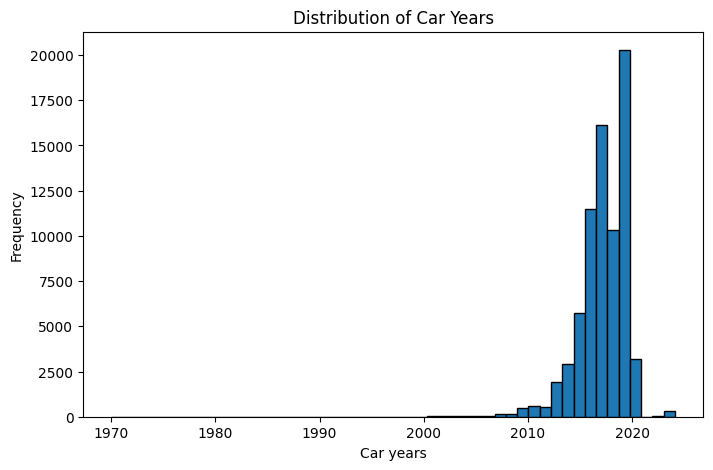

In [199]:
plt.figure(figsize=(8, 5))
plt.hist(df["year"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Years")
plt.xlabel("Car years")
plt.ylabel("Frequency")
plt.show()

In [200]:
old_cars = df[df["year"] > 20][["Brand", "model", "year","engineSize"]]
display(old_cars)
#os carros de 1970 nem existiam em 1970 como dito anteriormente

,Brand,model,year,engineSize
carID,,,,
69512,VW,GOLF,2016.0,2.0
53000,Toyota,YARIS,2019.0,1.5
6366,Audi,Q2,2019.0,1.5
29021,Ford,FIESTA,2018.0,1.0
10062,BMW,2SERIES,2019.0,1.5
...,...,...,...,...
37194,Mercedes,CCLASS,2015.0,2.0
6265,Audi,Q3,2013.0,2.0
54886,Toyota,AYGO,2017.0,1.0


In [201]:
df = limpar_anos(df,2020)
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
53282,Toyota,YARIS,<NA>,16995,Manual,1225.0,Petrol,145.000000,47.9,1.5,77.0,0.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,<NA>,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,<NA>,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,<NA>,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,<NA>,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,<NA>,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [202]:
df["year"].unique()

<IntegerArray>
[   4,    1,    2,    6,    3,    0,    7, <NA>,    5,    9,    8,   17,   11,
   13,   15,   16,   10,   12,   14,   19,   20,   18,   24,   22,   50,   21,
   23]
Length: 27, dtype: Int64

In [203]:
ordenado = df.sort_values("price", ascending=True)

baratos = ordenado[["Brand", "model", "year", "price"]].head(5)
caros = baratos[["Brand", "model", "year", "price"]].tail(5)
display(baratos)
display(caros)
#acho possível estes carros em especifico terem estes preços

,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,17,450
19562,Ford,FOCUS,17,495
23427,Ford,FOCUS,17,495
61005,Opel,CORSA,18,495
55950,Opel,CORSA,17,590


,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,17,450
19562,Ford,FOCUS,17,495
23427,Ford,FOCUS,17,495
61005,Opel,CORSA,18,495
55950,Opel,CORSA,17,590


#### Preprocessing **transmission**

In [204]:
df["transmission"].unique()

array(['Semi-Auto', 'Manual', 'anual', 'Semi-Aut', 'Automatic', 'manual',
       nan, 'unknown', 'Manua', 'AUTOMATIC', 'MANUAL', 'semi-auto',
       ' Manual ', 'automatic', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT',
       'Automati', 'ANUAL', 'utomatic', 'unknow', 'EMI-AUTO', 'manua',
       'anua', 'emi-Aut', 'MANUA', 'emi-auto', 'UTOMATIC', ' manual ',
       ' MANUAL ', 'UNKNOWN', 'nknown', 'automati', 'Other', 'semi-aut',
       ' Manual', 'AUTOMATI', 'utomati', 'Manual ', 'manual ', 'nknow'],
      dtype=object)

In [205]:
df[df["transmission"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,5,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,0,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,1,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,1,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


In [206]:
def HELPER_normalize_transmission(df):
    df = df.copy()
    df["transmission"] = (
        df["transmission"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [207]:
def HELPER_transmissao_correta(transm, valid_list, threshold):
    if pd.isna(transm):
        return np.nan

    if transm in valid_list:
        return transm
    
    result = process.extractOne(transm, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_transmissao(df, threshold=60):
    df=df.copy()
    df = HELPER_normalize_transmission(df)
    valid_list = ["MANUAL", "AUTOMATIC", "SEMI-AUTO", "OTHER", "UNKNOWN"]

    df["transmission"] = df["transmission"].apply(
        lambda x: HELPER_transmissao_correta(x, valid_list, threshold)
    )
    return df

In [208]:
df = fuzzy_transmissao(df)
df[df["transmission"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,5,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,0,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,1,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,1,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


In [209]:
df["transmission"].unique()

array(['SEMI-AUTO', 'MANUAL', 'AUTOMATIC', nan, 'UNKNOWN', 'OTHER'],
      dtype=object)

#### Preprocessing **mileage**

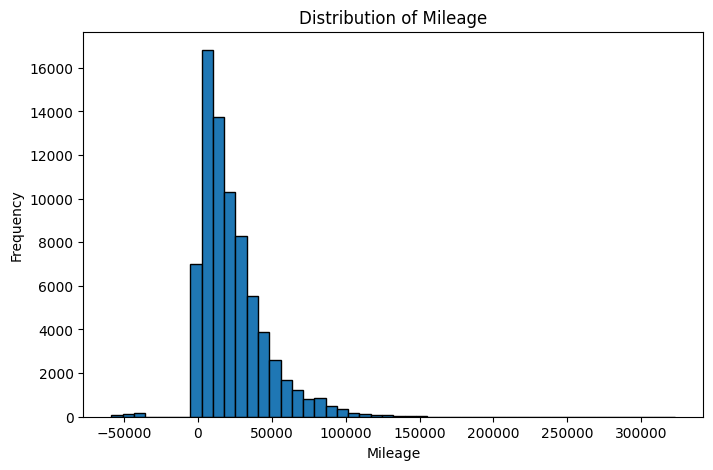

In [210]:
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

In [211]:
df[df["mileage"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,3,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,3,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,4,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,1,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33828,Hyundai,TUCSON,1,18390,MANUAL,NaN,Petrol,145.000000,34.9,1.6,86.0,4.0,0.0
55680,Toyota,CHR,3,20700,AUTOMATIC,NaN,Hybrid,135.000000,74.3,1.8,86.0,0.0,0.0
39353,Mercedes,GLCLASS,1,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0


In [212]:
df[df["mileage"] < 0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,TIGUAN,0,25000,MANUAL,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0,0.0
43529,Mercedes,CCLASS,1,25780,SEMI-AUTO,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0,0.0
71090,VW,GOLF,2,14995,MANUAL,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0,0.0
7845,BMW,3SERIES,1,23498,SEMI-AUTO,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN,0.0
24999,Ford,FIESTA,3,8895,MANUAL,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,None,2,8514,MANUAL,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0,NaN
45765,Mercedes,GLCLASS,0,54995,AUTOMATIC,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0,0.0
38413,Mercedes,SLK,5,17900,AUTOMATIC,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0,0.0


In [213]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

In [214]:
df=impossible_to_nan(df, "mileage")
df.loc[70615]

Brand                 VW
model             TIGUAN
year                   0
price              25000
transmission      MANUAL
mileage              NaN
fuelType          Petrol
tax                145.0
mpg                 38.2
engineSize           1.5
paintQuality%       89.0
previousOwners       3.0
hasDamage            0.0
Name: 70615, dtype: object

In [215]:
df[df["mileage"] < 0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,


In [216]:
df[df["mileage"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,3,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,3,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,4,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,1,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39353,Mercedes,GLCLASS,1,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0
9474,BMW,3SERIES,4,14000,MANUAL,NaN,Diese,316.487189,62.8,2.0,77.0,4.0,0.0
55820,Toyota,AYGO,1,8491,MANUAL,NaN,Petrol,145.000000,56.5,1.0,56.0,0.0,0.0


#### Preprocessing **fuelType**

In [217]:
df["fuelType"].unique()

array(['Petrol', 'Diesel', 'etrol', 'Hybrid', 'diesel', 'iesel', nan,
       'petrol', 'PETROL', 'Diese', 'Petro', 'DIESEL', 'petro', 'HYBRID',
       'ybri', 'Other', 'DIESE', 'Hybri', 'ETROL', 'ybrid', 'PETRO',
       'hybrid', 'IESEL', 'Electric', 'ther', 'iese', 'etro', 'ETRO',
       'diese', 'Othe', 'YBRID', 'HYBRI', 'OTHER', 'other', 'IESE'],
      dtype=object)

In [218]:
df[df["fuelType"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,3,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,3,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,3,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,4,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,5,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,3,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


In [219]:
df["fuelType"].value_counts()

fuelType
Petrol      37995
Diesel      28474
Hybrid       2043
PETROL        795
etrol         794
Petro         785
petrol        746
iesel         603
diesel        599
Diese         582
DIESEL        582
Other         150
HYBRID         50
hybrid         46
Hybri          43
ybrid          37
petro          18
etro           17
ETROL          16
IESEL          16
PETRO          14
DIESE          10
iese           10
diese           8
Othe            6
ther            6
Electric        4
YBRID           3
OTHER           3
other           2
HYBRI           2
ybri            1
ETRO            1
IESE            1
Name: count, dtype: int64

In [220]:
def HELPER_normalize_fueltype(df):
    df = df.copy()
    df["fuelType"] = (
        df["fuelType"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [221]:
def HELPER_fuel_correto(fuel, valid_list, threshold):
    if pd.isna(fuel):
        return np.nan

    if fuel in valid_list:
        return fuel
    
    result = process.extractOne(fuel, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_fuel(df, threshold=60):
    df = HELPER_normalize_fueltype(df)
    valid_list = ["PETROL", "DIESEL", "HYBRID", "OTHER", "ELECTRIC"]

    df["fuelType"] = df["fuelType"].apply(
        lambda x: HELPER_fuel_correto(x, valid_list, threshold)
    )
    return df

In [222]:
df=fuzzy_fuel(df)
df["fuelType"].unique()

array(['PETROL', 'DIESEL', 'HYBRID', nan, 'OTHER', 'ELECTRIC'],
      dtype=object)

In [223]:
df[df["fuelType"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,3,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,3,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,3,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,4,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,5,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,3,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


In [224]:
df["fuelType"].value_counts()

fuelType
PETROL      41181
DIESEL      30885
HYBRID       2225
OTHER         167
ELECTRIC        4
Name: count, dtype: int64

#### Preprocessing **tax**

In [225]:
df[df["tax"]==0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
55065,Toyota,CHR,3,15490,AUTOMATIC,59000.0,HYBRID,0.0,74.3,1.8,95.0,2.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,DIESEL,0.0,78.5,1.6,61.0,2.0,0.0
54783,Toyota,YARIS,6,10490,AUTOMATIC,34528.0,HYBRID,0.0,80.7,1.5,79.0,1.0,0.0
47148,Skoda,RAPID,4,7991,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0
19051,Ford,FIESTA,7,6500,MANUAL,43181.0,PETROL,0.0,65.7,1.0,88.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54268,Toyota,AYGO,3,6620,MANUAL,10266.0,PETROL,0.0,69.0,1.0,51.0,0.0,0.0
52992,Toyota,AYGO,4,8550,MANUAL,20680.0,PETROL,0.0,69.0,1.0,66.0,2.0,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.0,2.0,0.0


In [226]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

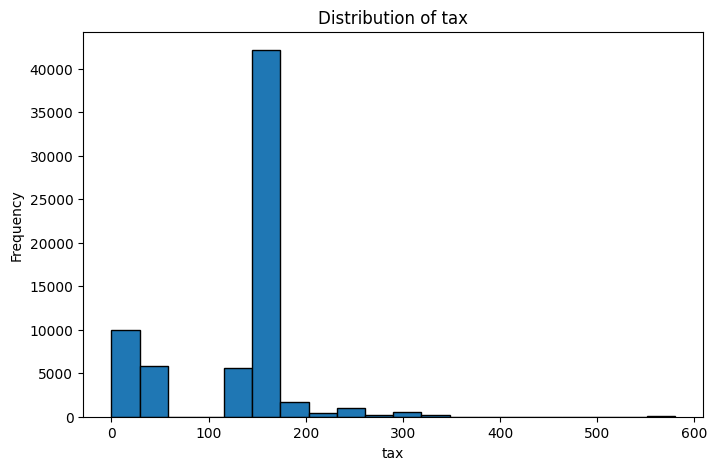

In [227]:
df=impossible_to_nan(df, "tax")

plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of tax")
plt.xlabel("tax")
plt.ylabel("Frequency")
plt.show()

In [228]:
g = df[df["tax"] == 0]
g["year"].value_counts()

year
4     1675
3     1046
5      827
6      391
7      221
8       29
9       20
10       8
11       5
2        2
Name: count, dtype: Int64

#### Preprocessing **mpg**

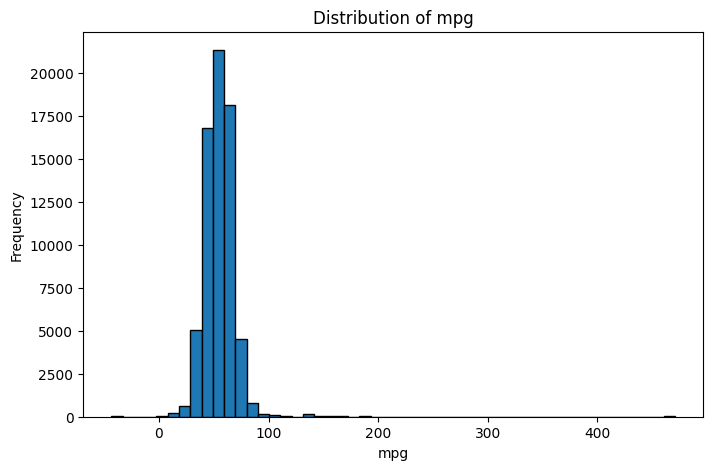

In [229]:
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()

In [230]:
df[df["mpg"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,3,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,1,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,4,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,1,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,3,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,1,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


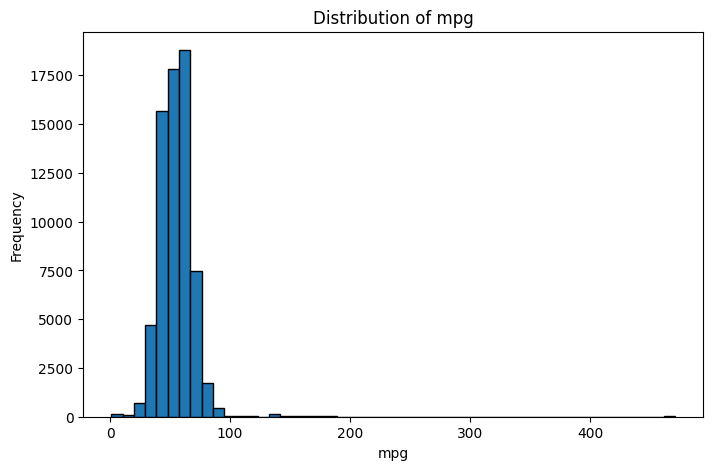

In [231]:
df=impossible_to_nan(df, "mpg")

plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()

In [232]:
df[df["mpg"]>=100]["fuelType"].value_counts()

fuelType
HYBRID      357
DIESEL       63
PETROL       40
OTHER        32
ELECTRIC      2
Name: count, dtype: int64

In [233]:
df[df["mpg"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,3,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,1,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,4,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,1,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,3,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,1,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


#### Preprocessing **engineSize**

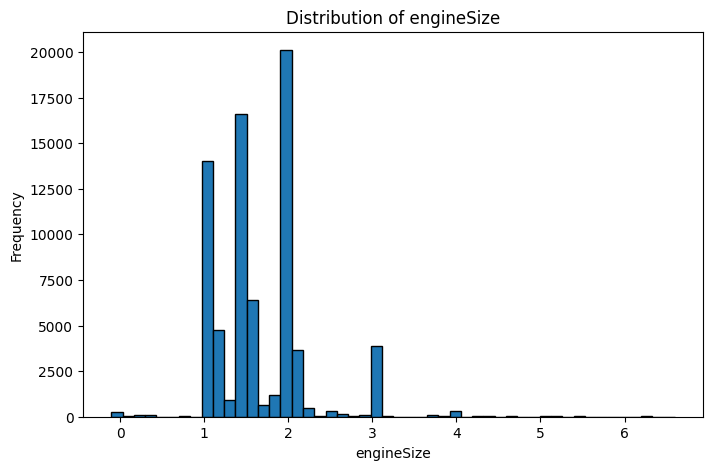

In [234]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

In [235]:
df[df["engineSize"] <1]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
61006,Opel,CORSA,1,9995,MANUAL,4366.0,PETROL,150.0,43.5,0.739534,66.0,3.0,0.0
30317,Ford,None,1,9999,MANUAL,10000.0,PETROL,145.0,47.9,0.000000,61.0,3.0,0.0
24113,Ford,KUGA,<NA>,14950,MANUAL,13411.0,DIESEL,125.0,60.1,-0.103493,83.0,1.0,0.0
3840,Audi,None,1,21262,MANUAL,4868.0,DIESEL,145.0,49.6,0.154529,58.0,2.0,0.0
21935,Ford,KA,2,8444,MANUAL,17000.0,PETROL,145.0,57.7,0.000000,51.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
46732,Skoda,OCTAVIA,2,11290,MANUAL,20047.0,PETROL,145.0,58.9,0.191462,98.0,0.0,0.0
38494,Mercedes,GLCLASS,4,19498,SEMI-AUTO,27846.0,DIESEL,125.0,56.5,0.307074,89.0,4.0,0.0
59040,Opel,GRANDLANDX,1,17289,MANUAL,14421.0,DIESEL,145.0,56.5,0.739534,74.0,0.0,0.0


In [236]:
df[df["engineSize"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,1,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,3,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
54844,Toyota,AYGO,3,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,3,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
70418,NaN,GOLF,4,16898,MANUAL,24180.0,DIESEL,20.0,67.3,NaN,83.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68840,VW,POLO,1,14999,MANUAL,4436.0,PETROL,150.0,52.3,NaN,98.0,2.0,0.0
61373,Opel,ASTRA,3,10800,MANUAL,19025.0,PETROL,125.0,50.4,NaN,36.0,0.0,0.0
68148,VW,GOLF,0,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0


In [237]:
df[df["engineSize"]>6]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
38980,Mercedes,CCLASS,7,23000,SEMI-AUTO,43442.000000,PETROL,NaN,NaN,6.2,76.0,0.0,0.0
46372,Mercedes,CCLASS,7,22995,SEMI-AUTO,49964.000000,PETROL,NaN,23.0,6.2,78.0,3.0,0.0
9197,BMW,7SERIES,3,57000,AUTOMATIC,11297.000000,PETROL,145.000000,22.1,6.6,68.0,1.0,0.0
42286,Mercedes,CCLASS,6,26998,SEMI-AUTO,24175.000000,PETROL,NaN,NaN,6.2,93.0,2.0,0.0
39900,Mercedes,CCLASS,6,28990,SEMI-AUTO,19562.000000,PETROL,NaN,NaN,6.2,83.0,0.0,0.0
39852,Mercedes,SCLASS,10,26990,AUTOMATIC,38000.000000,PETROL,570.000000,19.5,6.2,76.0,4.0,0.0
35612,Mercedes,CCLASS,7,23990,AUTOMATIC,NaN,PETROL,570.000000,23.5,6.2,44.0,2.0,0.0
36196,Mercedes,CCLASS,6,25885,SEMI-AUTO,86705.854885,PETROL,NaN,NaN,6.2,31.0,0.0,0.0
35538,NaN,CCLASS,<NA>,22995,SEMI-AUTO,49964.000000,PETROL,326.028233,NaN,6.2,58.0,3.0,0.0


In [238]:
df=impossible_to_nan(df, "engineSize", 1)
df[df["engineSize"].isna()]


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,1,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,3,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
61006,Opel,CORSA,1,9995,MANUAL,4366.0,PETROL,150.0,43.5,NaN,66.0,3.0,0.0
30317,Ford,None,1,9999,MANUAL,10000.0,PETROL,145.0,47.9,NaN,61.0,3.0,0.0
54844,Toyota,AYGO,3,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70592,VW,CADDYMAXI,5,9995,SEMI-AUTO,66000.0,DIESEL,200.0,48.7,NaN,34.0,3.0,0.0
68148,VW,GOLF,0,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0
10627,BMW,3SERIES,0,24990,SEMI-AUTO,22.0,DIESEL,150.0,54.3,NaN,90.0,1.0,0.0


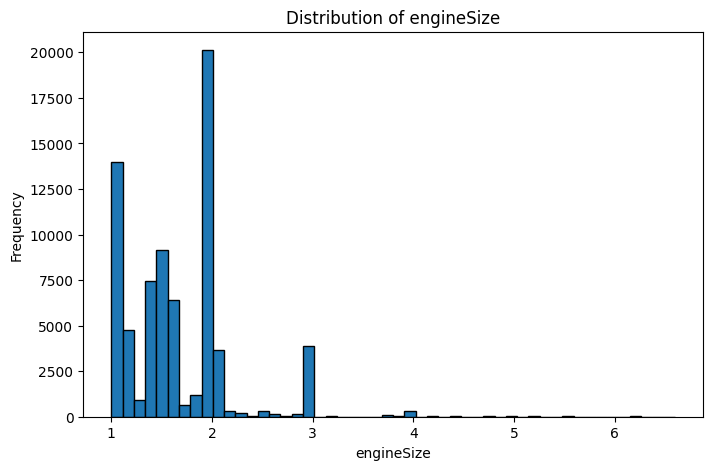

In [239]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

#### Preprocessing **paintQuality%**

In [240]:
def drop_paint(df):
    df.drop(columns=["paintQuality%"], errors="ignore")
    return df

In [241]:
df=drop_paint(df)

#### Preprocessing **previousOwners**

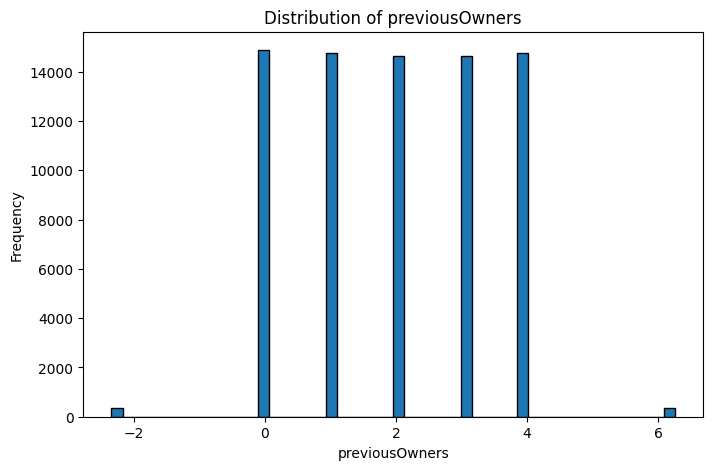

In [242]:
plt.figure(figsize=(8, 5))
plt.hist(df["previousOwners"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of previousOwners")
plt.xlabel("previousOwners")
plt.ylabel("Frequency")
plt.show()

In [243]:
df["previousOwners"].unique()

array([ 4.        ,  1.        , -2.34030622,  3.        ,  0.        ,
        2.        ,         nan, -2.34565   ,  6.25837066, -2.33512284,
        6.22789796,  6.25823052,  6.23017958, -2.33936045,  6.21772443,
        6.24583495, -2.29943868, -2.34010209, -2.31225953,  6.2482512 ,
       -2.31733109,  6.23308217,  6.24177863, -2.33744529])

In [244]:
df[df["previousOwners"]<0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.7,1.0,50.0,-2.340306,0.0
71677,VW,TIGUAN,1,29999,SEMI-AUTO,669.0,DIESEL,145.0,39.8,2.0,42.0,-2.345650,0.0
16962,Ford,FOCUS,1,19950,AUTOMATIC,7142.0,DIESEL,NaN,NaN,2.0,41.0,-2.340306,0.0
5994,Audi,None,0,31990,SEMI-AUTO,4432.0,PETROL,150.0,40.4,1.5,98.0,-2.335123,0.0
5038,Audi,RS6,0,97500,SEMI-AUTO,3220.0,PETROL,150.0,22.1,4.0,72.0,-2.335123,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67526,VW,PASSAT,0,20998,SEMI-AUTO,15.0,DIESEL,145.0,49.6,1.6,62.0,-2.345650,0.0
75599,VW,UP,5,6795,MANUAL,10800.0,PETROL,20.0,61.4,1.0,31.0,-2.345650,0.0
28295,Ford,SMAX,3,17950,MANUAL,28280.0,PETROL,145.0,43.5,1.5,45.0,-2.340306,0.0


In [245]:
df[df["previousOwners"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,AUTOMATIC,45000.0,PETROL,NaN,46.3,1.6,59.0,NaN,0.0
18304,Ford,None,4,9632,MANUAL,18814.0,PETROL,20.0,62.8,1.0,74.0,NaN,0.0
49135,Skoda,SCALA,0,17000,MANUAL,731.0,PETROL,150.0,50.4,1.0,88.0,NaN,0.0
37446,Mercedes,CCLASS,1,27099,SEMI-AUTO,1059.0,PETROL,145.0,45.6,1.5,87.0,NaN,0.0
1768,Audi,Q3,0,35990,SEMI-AUTO,6000.0,DIESEL,145.0,47.1,2.0,48.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,Audi,A7,6,19499,AUTOMATIC,47317.0,DIESEL,145.0,54.3,3.0,57.0,NaN,0.0
6295,Audi,A3,2,17650,MANUAL,6350.0,PETROL,150.0,55.4,1.5,60.0,NaN,0.0
21918,Ford,FIESTA,1,13998,MANUAL,10576.0,PETROL,145.0,58.9,1.0,65.0,NaN,0.0


In [246]:
def round_owners_int(df):
    df=df.copy()
    df["previousOwners"] = pd.to_numeric(df["previousOwners"], errors="coerce")

    df['previousOwners'] = df['previousOwners'].round().astype('Int64')
    return df

In [247]:
df=impossible_to_nan(df,"previousOwners")
df=round_owners_int(df)
df["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

#### Preprocessing **hasDamage**

In [248]:
df["hasDamage"].unique() #está cheia de zeros

array([ 0., nan])

In [249]:
def remove_hasdmg(df):
    df = df.copy()

    df = df.drop(columns=['hasDamage'])
    return df

In [250]:
df=remove_hasdmg(df)
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
69512,VW,GOLF,4,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,1,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,1,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,1,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,13498,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,7,12495,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,3,8399,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [251]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': (missing / len(df)) * 100
})

print("Missing Values with Percentage:\n")
print(missing_df)



Missing Values with Percentage:

                Missing Count  Missing Percentage
tax                      8282           10.901241
mpg                      7962           10.480039
engineSize               2090            2.750977
previousOwners           1921            2.528530
year                     1849            2.433759
mileage                  1832            2.411383
model                    1578            2.077054
paintQuality%            1524            2.005976
transmission             1522            2.003343
Brand                    1521            2.002027
fuelType                 1511            1.988864
price                       0            0.000000


In [252]:
def fill_cats_UNKNOWN(df, cats):
    df = df.copy()
    for column in cats:
        df[column] = df[column].fillna('UNKNOWN')
    
    return df

In [253]:
def mileage_per_year(df):
    age_divisor = np.maximum(df['year'],1)
    df["mileage_per_year"] = df["mileage"] / age_divisor
    return df

In [254]:
def power_efficiency(df):
    df["power_efficiency"] = df["engineSize"] / (df["mpg"])
    max_finite = df.loc[np.isfinite(df["power_efficiency"]), "power_efficiency"].max()
    df["power_efficiency"] = df["power_efficiency"].replace([np.inf], max_finite)
    
    return df

In [255]:
df=mileage_per_year(df)
df=power_efficiency(df)

In [256]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize','previousOwners',"mileage_per_year","power_efficiency"]
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize',"mileage_per_year","power_efficiency"]   

In [257]:
df=fill_cats_UNKNOWN(df, cat_cols)

In [258]:
def clean_df(df, valid_models, cat_cols):
    df=df.copy()
    df=carID_como_index(df)
    df=fuzzy_marcas(df)
    df=fuzzy_modelos(df, valid_models)
    #df=inferir_marca_com_modelo(df, valid_models)
    df=limpar_anos(df)
    df=fuzzy_transmissao(df)
    df=impossible_to_nan(df, "mileage")
    df=mileage_per_year(df)
    df=fuzzy_fuel(df)
    df=impossible_to_nan(df, "tax")
    df=impossible_to_nan(df, "mpg")
    df=impossible_to_nan(df, "engineSize", 1)
    df=power_efficiency(df)
    df=drop_paint(df)
    df=impossible_to_nan(df,"previousOwners")
    df=round_owners_int(df)
    df=remove_hasdmg(df)
    df=fill_cats_UNKNOWN(df,cat_cols)
    return df

In [259]:
og_df=clean_df(og_df, valid_models, cat_cols)

In [260]:
assert pd.testing.assert_frame_equal(df, og_df) is None

#### Preprocessing **price**

Separate **price** from **df**

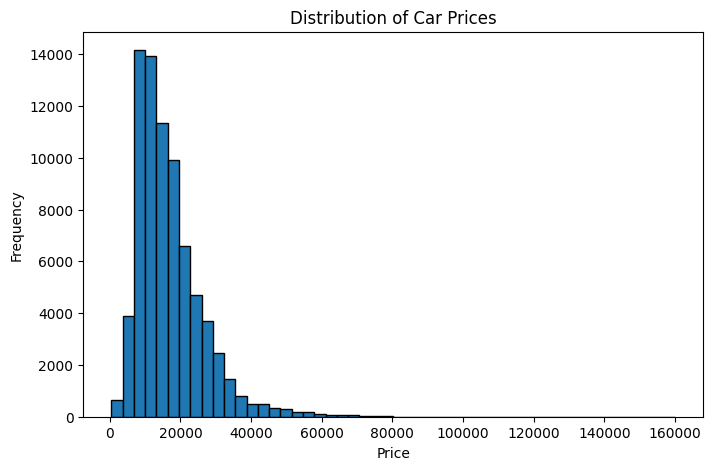

In [261]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [262]:
df["price"].describe()

count     75973.000000
mean      16881.889553
std        9736.926322
min         450.000000
25%       10200.000000
50%       14699.000000
75%       20950.000000
max      159999.000000
Name: price, dtype: float64

In [263]:
def separar_y(df):
    df=df.copy()

    X = df.drop('price', axis = 1)
    y = df['price']

    return X, y

In [264]:
X, y = separar_y(df)
X

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4,7105.25,0.175173
53000,Toyota,YARIS,1,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1,4589.0,0.031315
6366,Audi,Q2,1,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4,3624.0,0.036675
29021,Ford,FIESTA,2,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>,4551.0,0.015221
10062,BMW,2SERIES,1,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3,1000.0,0.035047
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0,2896.0,0.037523
6265,Audi,Q3,7,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2,7447.714286,0.041754
54886,Toyota,AYGO,3,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3,3768.0,0.014925


In [265]:
y

carID
69512    22290
53000    13790
6366     24990
29021    12500
10062    22995
         ...  
37194    13498
6265     12495
54886     8399
860      12990
15795    10495
Name: price, Length: 75973, dtype: int64

# Feature Selection

In [266]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.3, random_state = RANDOM_SEED, shuffle = True)

In [267]:
df.dtypes

Brand                object
model                object
year                  Int64
price                 int64
transmission         object
mileage             float64
fuelType             object
tax                 float64
mpg                 float64
engineSize          float64
paintQuality%       float64
previousOwners        Int64
mileage_per_year    Float64
power_efficiency    float64
dtype: object

In [268]:
def fill_nans(X, ints, floats, fill_values=None):
    X = X.copy()

    if fill_values is None:
        fill_values = {"float": {}, "int": {}}
        for column in floats:
            mean_to_fill = X[column].mean()
            X[column] = X[column].fillna(mean_to_fill)
            fill_values["float"][column] = mean_to_fill
    
        for column in ints:
            median_to_fill = X[column].median()
            X[column] = X[column].fillna(median_to_fill).astype("Int64")
            fill_values["int"][column] = median_to_fill

        return X, fill_values
    else:
        for col in floats:
            X[col] = X[col].fillna(fill_values["float"][col])
        for col in ints:
            X[col] = X[col].fillna(fill_values["int"][col]).astype("Int64")

        return X

In [313]:
X_train, fill_values = fill_nans(X_train, int_cols, float_cols)
X_val = fill_nans(X_val, int_cols, float_cols, fill_values)

In [314]:
X_train.info()
X_train.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 53181 entries, 39423 to 35376
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             53181 non-null  object 
 1   model             53181 non-null  object 
 2   year              53181 non-null  Int64  
 3   transmission      53181 non-null  object 
 4   mileage           53181 non-null  float64
 5   fuelType          53181 non-null  object 
 6   tax               53181 non-null  float64
 7   mpg               53181 non-null  float64
 8   engineSize        53181 non-null  float64
 9   paintQuality%     52139 non-null  float64
 10  previousOwners    53181 non-null  Int64  
 11  mileage_per_year  53181 non-null  Float64
 12  power_efficiency  53181 non-null  float64
dtypes: Float64(1), Int64(2), float64(6), object(4)
memory usage: 7.8+ MB


,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
count,53181.0,53181.000000,5.318100e+04,53181.000000,53181.000000,52139.000000,53181.0,53181.0,53181.000000
mean,2.925537,2.332153,8.818153e-18,54.544520,1.661938,64.482321,2.015099,7657.920557,0.033031
std,2.132121,0.196317,1.000009e+00,11.067234,0.511976,21.025020,1.423351,5772.678171,0.015646
min,0.0,0.526589,-1.927008e+00,1.100000,1.000000,1.638913,0.0,0.052632,0.005947
25%,1.0,2.299356,-3.521020e-02,47.100000,1.300000,47.000000,1.0,4444.0,0.022414
50%,3.0,2.379547,3.555444e-01,55.181389,1.600000,64.000000,2.0,7092.25,0.031847
75%,4.0,2.431357,3.555444e-01,61.400000,2.000000,82.000000,3.0,9762.4,0.036101
max,50.0,2.616330,8.878088e+00,78.500000,3.000000,125.594308,6.0,132644.0,0.102041


In [315]:
def plot_nums(X, num_cols):
    outlier_counts=[]
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(col, fontsize=14, fontweight='bold')

        # Boxplot
        sns.boxplot(y=X[col], ax=axes[0], color='skyblue')
        axes[0].set_title("Boxplot")

        # Histogram
        sns.histplot(X[col], kde=True, ax=axes[1], color='salmon')
        axes[1].set_title("Histogram")
    plt.tight_layout()
    plt.show()
    for item in num_cols:
    #   find and count the outliers of metric features
        q1 = X[item].quantile(0.25)
        q3 = X[item].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        lower_outliers = (X[item] < lower).sum()
        upper_outliers = (X[item] > upper).sum()
        lower_pct = (lower_outliers / len(X)) * 100
        upper_pct = (upper_outliers / len(X)) * 100
        #create a dictionary with the feature,#outlier and percentage of outliers
        outlier_counts.append({
        "Feature": item,
        "Lower Outlier Count": lower_outliers,
        "Upper Outlier Count": upper_outliers,
        "Lower Outlier %": lower_pct,
        "Upper Outlier %": upper_pct
    })
    df_outlier = pd.DataFrame(outlier_counts) 
    return df_outlier

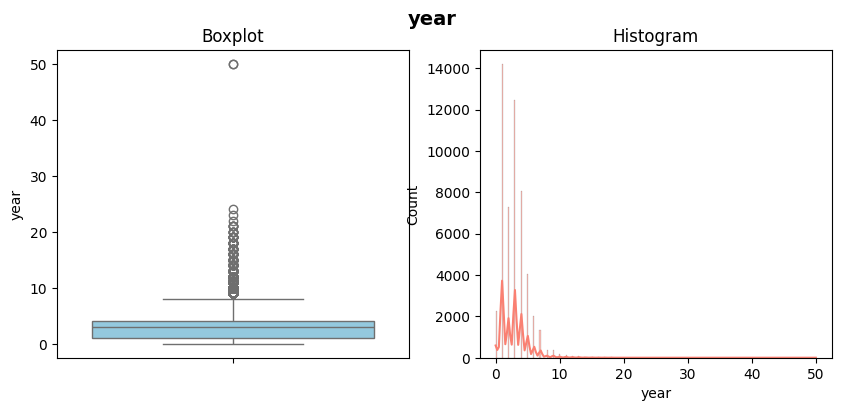

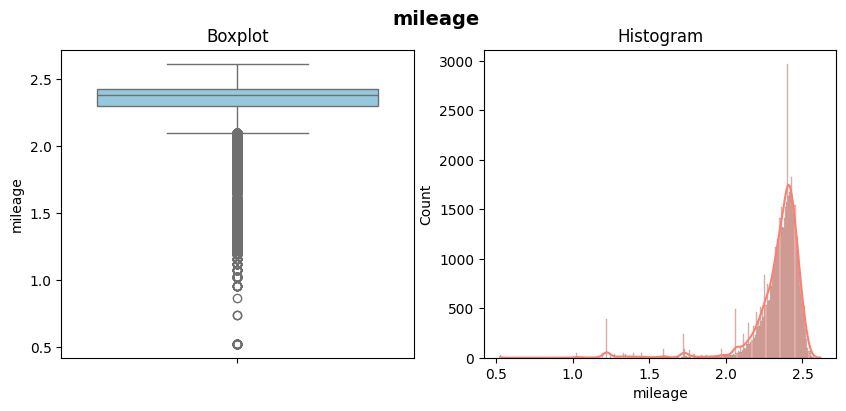

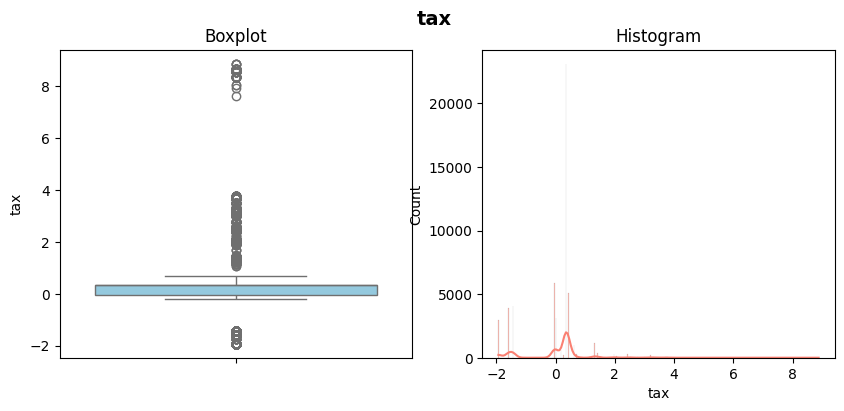

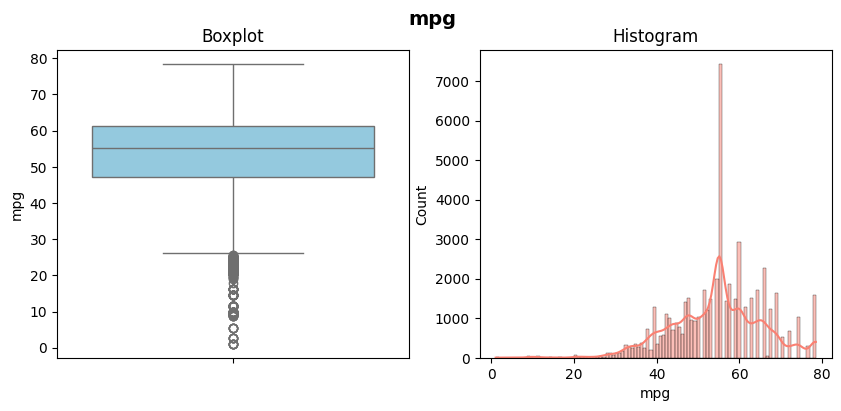

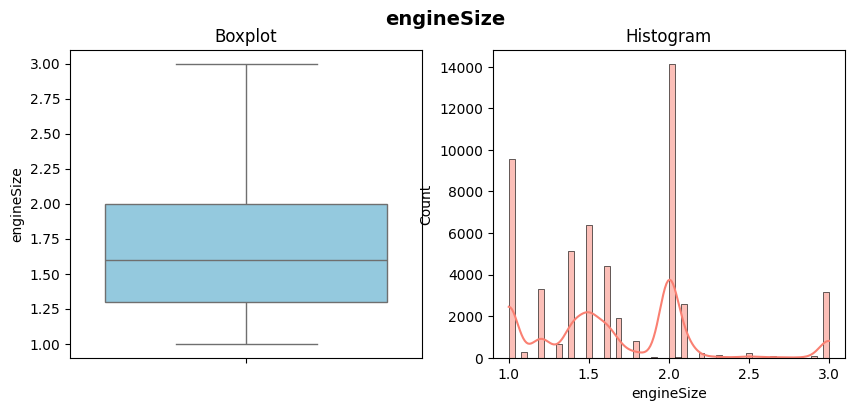

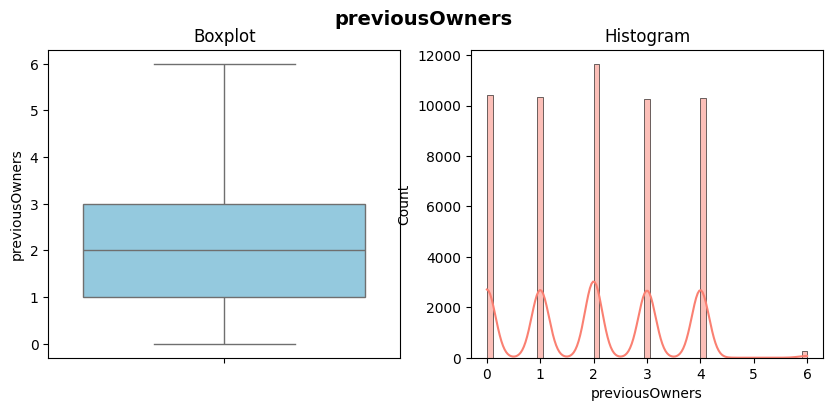

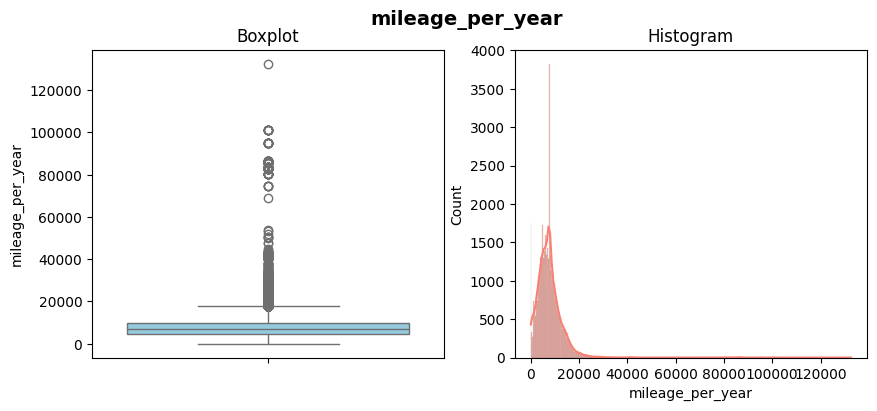

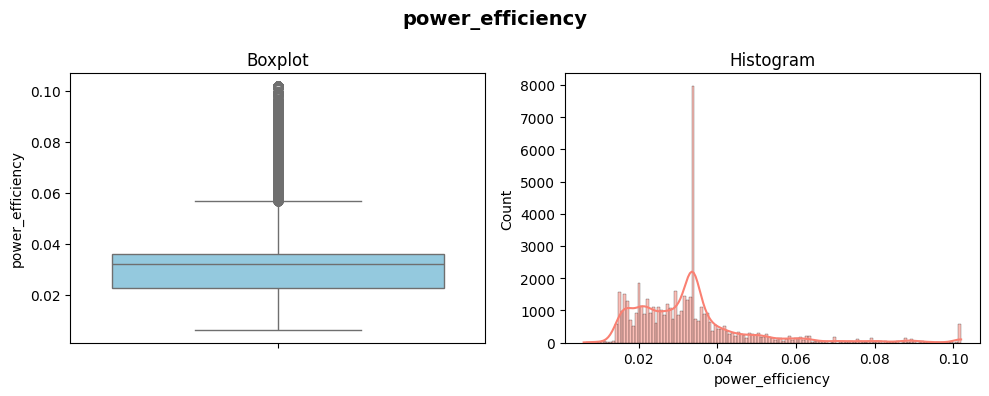

,Feature,Lower Outlier Count,Upper Outlier Count,Lower Outlier %,Upper Outlier %
0,year,0,1082,0.000000,2.034561
1,mileage,3108,0,5.844192,0.000000
2,tax,10941,2942,20.573137,5.532051
3,mpg,353,0,0.663771,0.000000
4,engineSize,0,0,0.000000,0.000000
5,previousOwners,0,0,0.000000,0.000000
6,mileage_per_year,0,1666,0.000000,3.132698
7,power_efficiency,0,3853,0.000000,7.245069


In [316]:
plot_nums(X_train, num_cols)

In [317]:
X_train.describe()

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
count,53181.0,53181.000000,5.318100e+04,53181.000000,53181.000000,52139.000000,53181.0,53181.0,53181.000000
mean,2.925537,2.332153,8.818153e-18,54.544520,1.661938,64.482321,2.015099,7657.920557,0.033031
std,2.132121,0.196317,1.000009e+00,11.067234,0.511976,21.025020,1.423351,5772.678171,0.015646
min,0.0,0.526589,-1.927008e+00,1.100000,1.000000,1.638913,0.0,0.052632,0.005947
25%,1.0,2.299356,-3.521020e-02,47.100000,1.300000,47.000000,1.0,4444.0,0.022414
50%,3.0,2.379547,3.555444e-01,55.181389,1.600000,64.000000,2.0,7092.25,0.031847
75%,4.0,2.431357,3.555444e-01,61.400000,2.000000,82.000000,3.0,9762.4,0.036101
max,50.0,2.616330,8.878088e+00,78.500000,3.000000,125.594308,6.0,132644.0,0.102041


In [ ]:
def infer_brand_fit(df_train):
    model_to_brand = (
        df_train[df_train["Brand"] != "UNKNOWN"]
        .groupby("model")["Brand"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "UNKNOWN")
        .to_dict()
    )
    return model_to_brand


def infer_brand_apply(df, model_to_brand):
    df = df.copy()
    df["Brand"] = df.apply(
        lambda row: (
            row["Brand"]
            if row["Brand"] != "UNKNOWN"
            else model_to_brand.get(row["model"], "UNKNOWN")
        ),
        axis=1
    )
    return df

In [319]:
X_train[X_train["Brand"] =="UNKNOWN"]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,,
4297,UNKNOWN,A5,4,SEMI-AUTO,2.417501,PETROL,2.436173,35.800000,3.0,90.0,1,6846.25,0.083799
3538,UNKNOWN,Q5,3,MANUAL,2.478134,PETROL,1.966602,37.700000,2.0,95.0,4,7657.920557,0.053050
31896,UNKNOWN,SANTAFE,1,SEMI-AUTO,2.289567,DIESEL,0.355544,39.200000,2.2,39.0,0,7119.0,0.056122
35310,UNKNOWN,CCLASS,7,AUTOMATIC,2.495457,DIESEL,-0.035210,55.181389,2.1,87.0,3,9714.285714,0.033805
40719,UNKNOWN,CCLASS,4,AUTOMATIC,2.426725,DIESEL,-0.035210,55.181389,2.1,75.0,1,7596.25,0.033805
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14626,UNKNOWN,1SERIES,7,AUTOMATIC,2.487811,DIESEL,-1.431114,64.200000,2.0,65.0,3,8857.142857,0.031153
48145,UNKNOWN,KODIAQ,1,MANUAL,2.199911,DIESEL,0.355544,52.300000,2.0,32.0,0,3053.0,0.038241
37742,UNKNOWN,GLACLASS,6,SEMI-AUTO,2.474251,DIESEL,0.355544,55.400000,2.1,35.0,1,8787.0,0.037906


In [320]:
model_to_brand = infer_brand_fit(X_train)
X_train = infer_brand_apply(X_train, model_to_brand)
X_val   = infer_brand_apply(X_val, model_to_brand)
X_train[X_train["Brand"] == "UNKNOWN"]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,,
69305,UNKNOWN,TIGUA,4,SEMI-AUTO,2.403083,DIESEL,0.612861,49.6,2.000000,86.000000,3,7657.920557,0.040323
35445,UNKNOWN,CCLAS,7,AUTOMATIC,2.495457,DIESEL,0.355544,53.3,2.100000,94.000000,1,9714.285714,0.039400
38260,UNKNOWN,CLCLASS,3,SEMI-AUTO,2.404122,DIESEL,-1.586047,67.3,2.100000,91.000000,0,7864.0,0.031204
36973,UNKNOWN,GLACLASS,1,SEMI-AUTO,2.376612,DIESEL,0.355544,67.3,2.100000,70.000000,2,17471.0,0.031204
5908,UNKNOWN,A,5,SEMI-AUTO,2.480617,DIESEL,0.440671,53.3,2.000000,69.000000,0,11375.0,0.037523
39351,UNKNOWN,GLECLASS,5,AUTOMATIC,2.350323,PETROL,8.668387,23.7,1.672358,80.000000,2,2642.4,0.033805
62403,UNKNOWN,ASTR,4,MANUAL,2.433700,DIESEL,-1.586047,72.4,1.600000,76.000000,3,8222.75,0.022099
37971,UNKNOWN,CLSCLASS,1,AUTOMATIC,2.425598,DIESEL,0.440671,47.9,2.900000,74.000000,1,30000.0,0.060543
14098,UNKNOWN,X,6,AUTOMATIC,2.446067,DIESEL,0.699855,52.3,2.000000,87.000000,0,6317.5,0.038241


In [ ]:
def outliers_skews_train(X):
    X = X.copy()
    outlier_info = {}

    if "mileage" in X.columns:
        X["mileage"] = np.log1p(X["mileage"])
        outlier_info["mileage"] = {"log1p_transform": True}

    if "tax" in X.columns:
        pt = PowerTransformer(method="yeo-johnson")
        X["tax"] = pt.fit_transform(X[["tax"]]).flatten()
        outlier_info["tax"] = pt

    if "mpg" in X.columns:
        upper = X["mpg"].quantile(0.975)
        X["mpg"] = X["mpg"].clip(upper=upper)
        outlier_info["mpg"] = {"upper": upper}

    if "engineSize" in X.columns:
        lower = X["engineSize"].quantile(0.01)
        upper = X["engineSize"].quantile(0.99)
        X["engineSize"] = X["engineSize"].clip(lower=lower, upper=upper)
        outlier_info["engineSize"] = {"lower": lower, "upper": upper}
       
    if "milleage_per_year" in X.columns:
        X["milleage_per_year"] = np.log1p(X["milleage_per_year"])
        outlier_info["milleage_per_year"] = {"log1p_transform": True}

    if "power_efficiency" in X.columns:
        upper = X["power_efficiency"].quantile(0.99)
        X["power_efficiency"] = X["power_efficiency"].clip(upper=upper)
        outlier_info["power_efficiency"] = {"upper": upper}
    return X, outlier_info

def outliers_skews_test(X, outlier_info):
    X = X.copy()


    if "mileage" in outlier_info and "mileage" in X.columns:
        if outlier_info["mileage"].get("log1p_transform", True):
            X["mileage"] = np.log1p(X["mileage"])

    if "tax" in outlier_info and "tax" in X.columns:
        pt = outlier_info["tax"]
        X["tax"] = pt.transform(X[["tax"]]).flatten()

    if "mpg" in outlier_info and "mpg" in X.columns:
        X["mpg"] = X["mpg"].clip(upper=outlier_info["mpg"]["upper"])
        
    if "engineSize" in outlier_info and "engineSize" in X.columns:
        X["engineSize"] = X["engineSize"].clip(
            lower=outlier_info["engineSize"]["lower"],
            upper=outlier_info["engineSize"]["upper"])

    if "milleage_per_year" in outlier_info and "milleage_per_year" in X.columns:
        if outlier_info["milleage_per_year"].get("log1p_transform", True):
            X["milleage_per_year"] = np.log1p(X["milleage_per_year"])
            
    if "power_efficiency" in outlier_info and "power_efficiency" in X.columns:
        X["power_efficiency"] = X["power_efficiency"].clip(upper=outlier_info["power_efficiency"]["upper"])

    return X

In [278]:
X_train, outlier_info = outliers_skews_train(X_train)
X_val = outliers_skews_test(X_val, outlier_info)

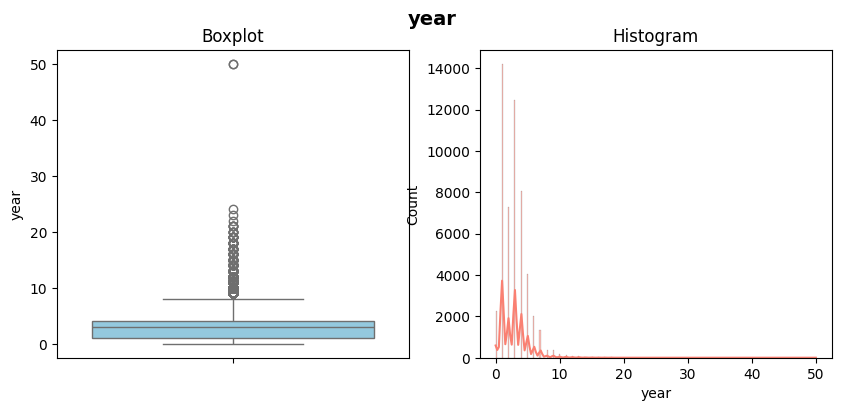

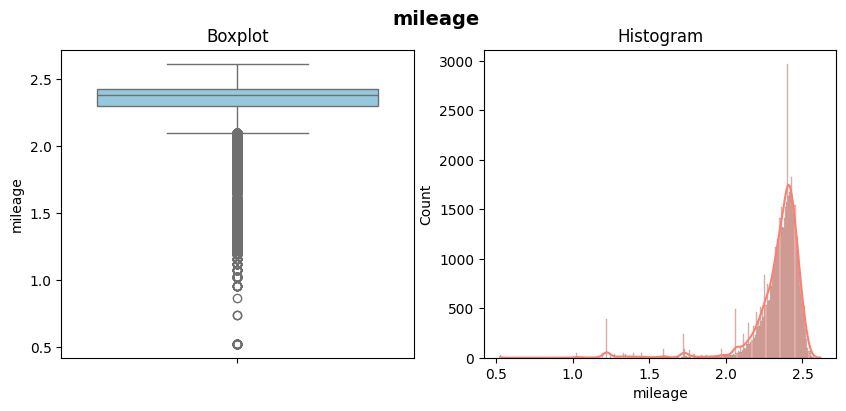

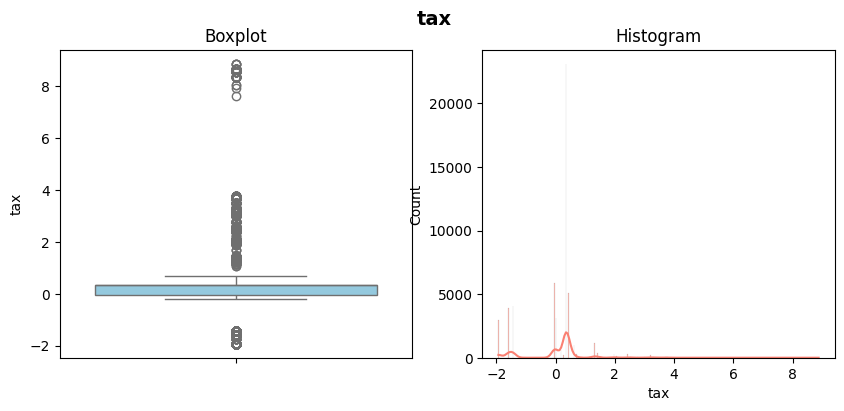

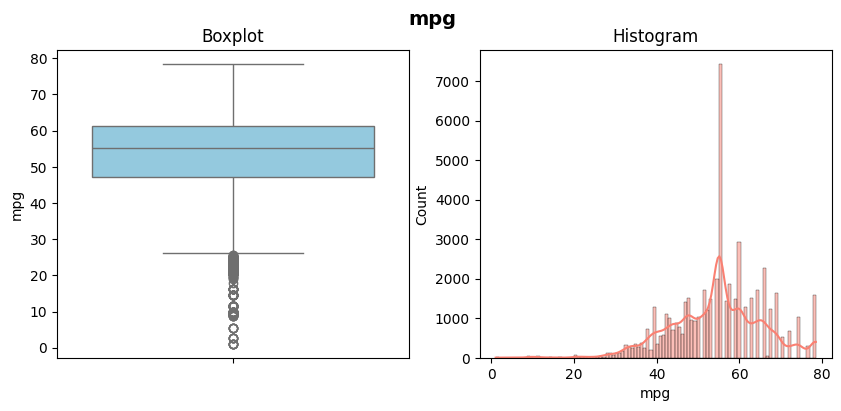

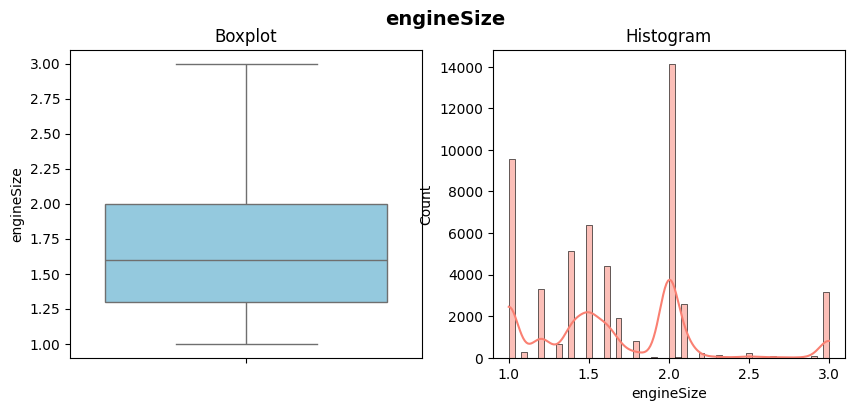

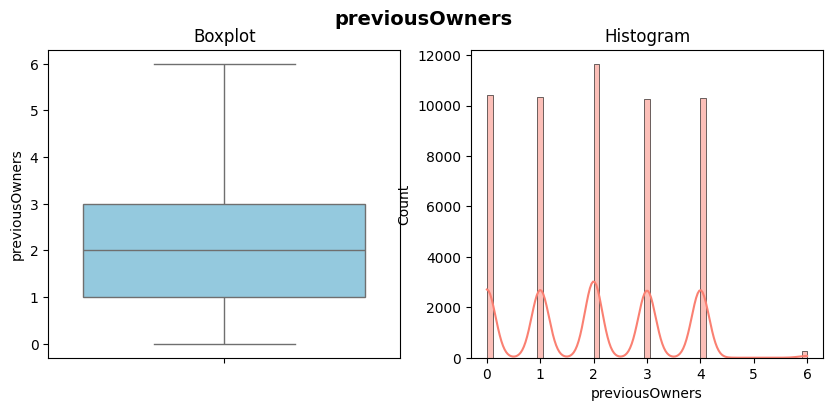

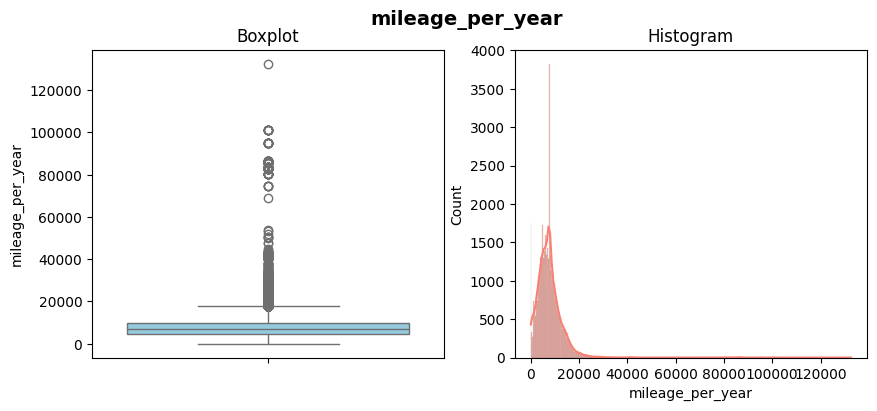

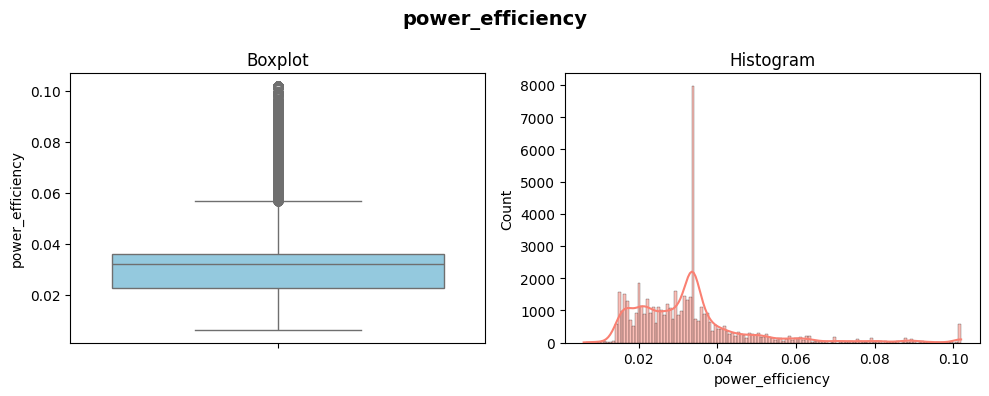

,Feature,Lower Outlier Count,Upper Outlier Count,Lower Outlier %,Upper Outlier %
0,year,0,1082,0.000000,2.034561
1,mileage,3108,0,5.844192,0.000000
2,tax,10941,2942,20.573137,5.532051
3,mpg,353,0,0.663771,0.000000
4,engineSize,0,0,0.000000,0.000000
5,previousOwners,0,0,0.000000,0.000000
6,mileage_per_year,0,1666,0.000000,3.132698
7,power_efficiency,0,3853,0.000000,7.245069


In [280]:
plot_nums(X_train, num_cols)

In [281]:
X_train_num = X_train[num_cols].copy()
X_train_cat = X_train[cat_cols].copy()

X_val_num = X_val[num_cols].copy()
X_val_cat = X_val[cat_cols].copy()

In [282]:
scaler = MinMaxScaler()
scaler.fit(X_train_num)
X_train_num_scaled = scaler.transform(X_train_num)
X_train_num_scaled

array([[2.00000000e-02, 8.13736676e-01, 2.11247807e-01, ...,
        3.33333333e-01, 2.95147080e-02, 2.20540959e-01],
       [2.00000000e-02, 8.32622721e-01, 1.95689700e-01, ...,
        5.00000000e-01, 4.28737796e-02, 7.07607633e-02],
       [0.00000000e+00, 3.33326983e-01, 2.11247807e-01, ...,
        0.00000000e+00, 7.49930066e-05, 1.22295392e-01],
       ...,
       [1.00000000e-01, 9.28575411e-01, 3.15556544e-02, ...,
        1.66666667e-01, 7.30206509e-02, 1.03818093e-01],
       [6.00000000e-02, 9.17748840e-01, 1.80427924e-01, ...,
        6.66666667e-01, 9.34904880e-02, 2.21555381e-01],
       [1.00000000e-01, 9.24557157e-01, 1.80427924e-01, ...,
        0.00000000e+00, 6.61662107e-02, 3.01731566e-01]])

In [283]:
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns = X_train_num.columns).set_index(X_train.index)
X_train_num_scaled

,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,
39423,0.02,0.813737,0.211248,0.604651,0.15,0.333333,0.029515,0.220541
9016,0.02,0.832623,0.195690,1.000000,0.50,0.500000,0.042874,0.070761
24121,0.00,0.333327,0.211248,0.715762,0.00,0.000000,0.000075,0.122295
57460,0.04,0.894623,0.211248,0.492248,0.20,0.000000,0.081421,0.309771
1936,0.00,0.799802,0.211248,0.361757,0.95,0.166667,0.022617,0.975186
...,...,...,...,...,...,...,...,...
33819,0.06,0.889844,0.175084,0.649871,0.20,0.666667,0.048669,0.221555
46982,0.02,0.573695,0.211248,0.538760,0.50,0.333333,0.000754,0.424396
71103,0.10,0.928575,0.031556,0.797158,0.00,0.166667,0.073021,0.103818


In [284]:
X_val_num_scaled = scaler.transform(X_val_num)
X_val_num_scaled = pd.DataFrame(X_val_num_scaled, columns = X_val_num.columns).set_index(X_val.index)
X_val_num_scaled

,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,
7082,0.02,0.829340,0.211248,0.453488,0.50,0.166667,0.040137,0.513056
40497,0.08,0.902972,0.175084,0.698726,0.55,0.500000,0.049389,0.289903
46065,0.10,0.923169,0.951553,0.357881,1.00,0.500000,0.063963,1.000000
17155,0.04,0.889520,0.211248,0.687339,0.00,0.666667,0.072468,0.129758
34462,0.04,0.912741,0.211248,0.472868,0.75,0.166667,0.124381,0.628197
...,...,...,...,...,...,...,...,...
50530,0.06,0.890272,0.211248,0.779070,0.00,0.333333,0.049144,0.107596
41012,0.02,0.794253,0.211248,0.698726,0.50,0.333333,0.020385,0.289903
68389,0.06,0.913085,0.031556,0.815245,0.00,0.333333,0.083604,0.100204


In [285]:
X_train_num_scaled.var()

year                0.001818
mileage             0.008825
tax                 0.008565
mpg                 0.020445
engineSize          0.065530
previousOwners      0.056276
mileage_per_year    0.001894
power_efficiency    0.026511
dtype: float64

In [286]:
X_train_num.var()

year                       4.545941
mileage                    0.038541
tax                        1.000019
mpg                      122.483658
engineSize                  0.26212
previousOwners             2.025928
mileage_per_year    33323813.264794
power_efficiency           0.000245
dtype: Float64

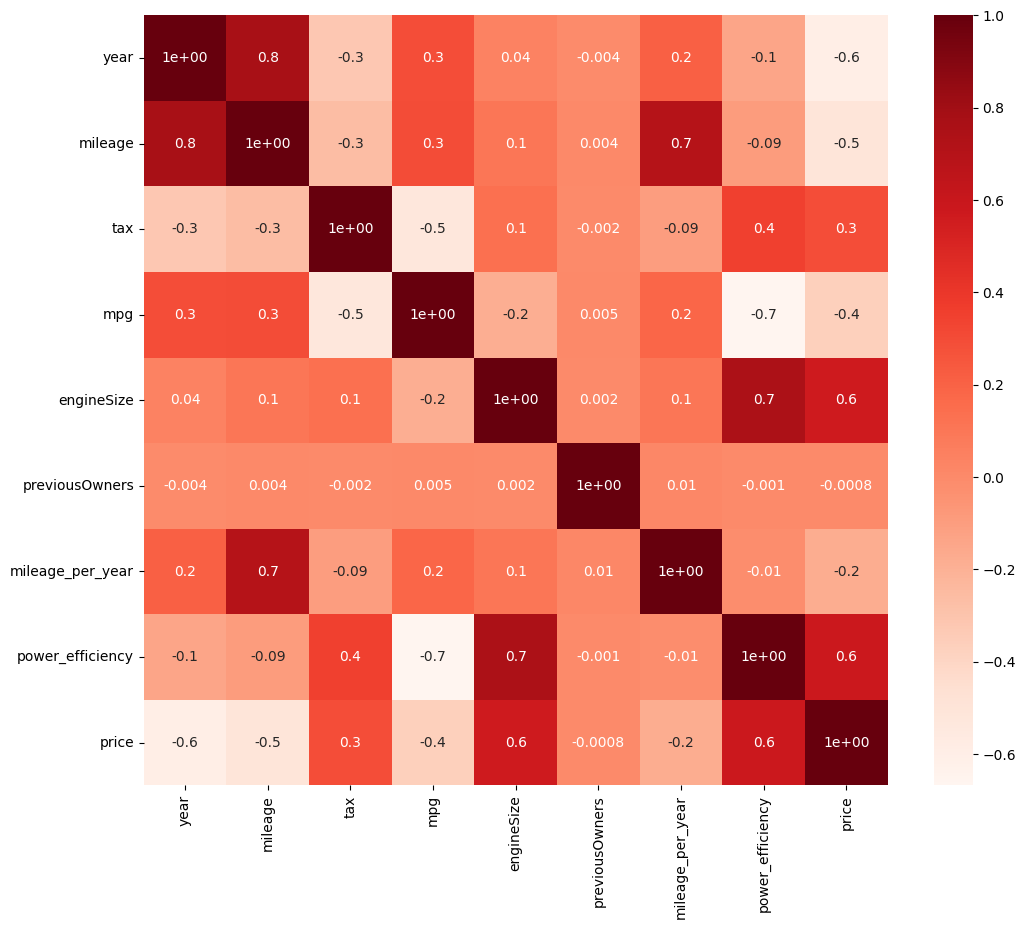

In [287]:
corr = X_train_num_scaled.assign(price=y_train).corr(method='spearman')
def cor_heatmap(cor):
    plt.figure(figsize=(12,10))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show()
cor_heatmap(corr)

In [288]:
mi_scores = mutual_info_regression(X_train_num_scaled, y_train, random_state=0)
mi_scores = pd.Series(mi_scores, index=X_train_num_scaled.columns)
mi_scores.sort_values(ascending=False, inplace=True)
print(mi_scores)
#How much knowing feature X reduces uncertainty about y

power_efficiency    0.664102
engineSize          0.379064
mpg                 0.362913
year                0.328162
mileage             0.303920
tax                 0.191451
mileage_per_year    0.153318
previousOwners      0.000000
dtype: float64


In [289]:
def TestIndependence(X,y,var,alpha=0.05):        
    dfObserved = pd.crosstab(y,X) 
    chi2, p, dof, expected = stats.chi2_contingency(dfObserved.values)
    dfExpected = pd.DataFrame(expected, columns=dfObserved.columns, index = dfObserved.index)
    if p<alpha:
        result="{0} is IMPORTANT for Prediction".format(var)
    else:
        result="{0} is NOT an important predictor. (Discard {0} from model)".format(var)
    print(result)

for var in X_train_cat:
    TestIndependence(X_train_cat[var],y_train, var)

Brand is IMPORTANT for Prediction
model is IMPORTANT for Prediction
transmission is IMPORTANT for Prediction
fuelType is NOT an important predictor. (Discard fuelType from model)


In [290]:
def cramers_v(x, y, var):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    result =  np.sqrt(chi2 / (n * (min(k - 1, r - 1))))
    print(f"{var}: {result}")

for var in X_train_cat:
    cramers_v(X_train_cat[var],y_train, var)

#How strongly is a categorical feature associated with the target? 0≤V≤1

Brand: 0.4875190701555071
model: 0.48039650498397557
transmission: 0.4831311924601659
fuelType: 0.4022624471229654


In [291]:
def mutual_info(X, y, var):
    le = LabelEncoder()
    X_encoded = le.fit_transform(X.astype(str)).reshape(-1, 1)

    mi = mutual_info_classif(X_encoded, y, discrete_features=True, random_state=RANDOM_SEED)
    print(f"{var}: {mi[0]:.4f}")

for var in X_train_cat:
    mutual_info(X_train_cat[var],y_train, var)

Brand: 0.7570
model: 1.9105
transmission: 0.4324
fuelType: 0.2402


In [292]:
def anova(X_col, y, var):
    groups = [y[X_col == level] for level in X_col.dropna().unique()]

    # Perform one-way ANOVA
    f_stat, p_val = f_oneway(*groups)

    print(f"{var.upper()}")
    print(f"  F-stat:  {f_stat:.3f}")
    print(f"  p-value: {p_val:.6f}")
    print("\n")  # line spacing between variables

    return pd.Series({"F-stat": f_stat, "p-value": p_val}, name=var)


for var in X_train_cat:
    anova(X_train_cat[var],y_train, var)

BRAND
  F-stat:  2319.533
  p-value: 0.000000


MODEL
  F-stat:  361.425
  p-value: 0.000000


TRANSMISSION
  F-stat:  5691.801
  p-value: 0.000000


FUELTYPE
  F-stat:  516.946
  p-value: 0.000000




In [293]:
model = LinearRegression()

In [294]:
rfe = RFE(estimator = model, n_features_to_select = 5)

In [295]:
X_rfe = rfe.fit_transform(X = X_train_num_scaled, y = y_train)

In [296]:
X_train_num_scaled.columns

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners',
       'mileage_per_year', 'power_efficiency'],
      dtype='object')

In [297]:
rfe.support_

array([ True,  True, False, False,  True, False,  True,  True])

In [298]:
rfe.ranking_

array([1, 1, 2, 3, 1, 4, 1, 1])

In [299]:
selected_features = pd.Series(rfe.support_, index = X_train_num_scaled.columns)
selected_features

year                 True
mileage              True
tax                 False
mpg                 False
engineSize           True
previousOwners      False
mileage_per_year     True
power_efficiency     True
dtype: bool

In [300]:
nof_list = np.arange(1, len(X_train_num_scaled.columns) + 1)
best_score = np.inf
best_n = 0

train_score_list = []
val_score_list = []

for n in nof_list:
    model = LinearRegression()
    rfe = RFE(estimator=model, n_features_to_select=n)
    
    # Fit RFE on training data
    X_train_rfe = rfe.fit_transform(X_train_num_scaled, y_train)
    X_val_rfe = rfe.transform(X_val_num_scaled)
    
    # Fit model
    model.fit(X_train_rfe, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train_rfe)
    y_val_pred = model.predict(X_val_rfe)
    
    # Compute RMSE manually
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    # Store negated RMSE (so higher = better for plotting)
    train_score_list.append(-train_rmse)
    val_score_list.append(-val_rmse)
    
    # Track best score (lowest RMSE)
    if val_rmse < best_score:
        best_score = val_rmse
        best_n = n

print(f"Optimum number of features: {best_n}")
print(f"Lowest validation RMSE ({best_n} features): {best_score:.4f}")


Optimum number of features: 6
Lowest validation RMSE (6 features): 5273.0729


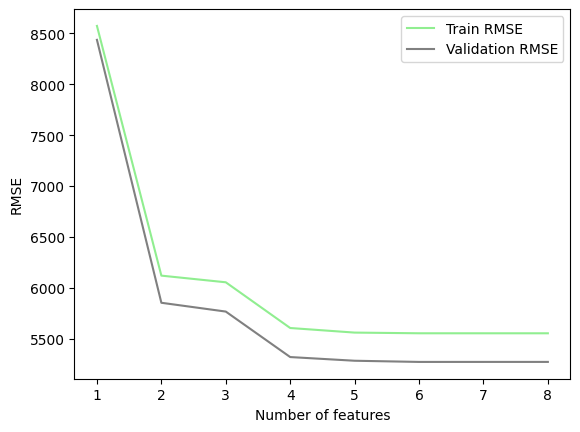

'Acho que há colinearidade entre variáveis como vimos antes'

In [301]:
plt.plot(nof_list, [-s for s in train_score_list], label='Train RMSE', color='lightgreen')
plt.plot(nof_list, [-s for s in val_score_list], label='Validation RMSE', color='gray')
plt.xlabel('Number of features')
plt.ylabel('RMSE')
plt.legend()
plt.show()

"""Acho que há colinearidade entre variáveis como vimos antes"""

In [302]:
"""SVR demora muito"""

'SVR demora muito'

In [303]:
#not sure if allowed
"""#EFS é exaustivo, tenta TODAS as combinações de preditores, não usar cross validation aqui para não ter data leakage
#é permitido?
efs = EFS(
    estimator=model,
    min_features=1,
    max_features=len(X_train_num_scaled.columns),
    scoring=make_scorer(mean_squared_error, greater_is_better=False),
    n_jobs=-1            # parallelize
)

efs = efs.fit(X_train_num_scaled, y_train)  
rmse_train = np.sqrt(-efs.best_score_)

print("Best features:", efs.best_feature_names_)
print(f"Training RMSE: {rmse_train:.2f}")
"""

'#EFS é exaustivo, tenta TODAS as combinações de preditores, não usar cross validation aqui para não ter data leakage\n#é permitido?\nefs = EFS(\n    estimator=model,\n    min_features=1,\n    max_features=len(X_train_num_scaled.columns),\n    scoring=make_scorer(mean_squared_error, greater_is_better=False),\n    n_jobs=-1            # parallelize\n)\n\nefs = efs.fit(X_train_num_scaled, y_train)  \nrmse_train = np.sqrt(-efs.best_score_)\n\nprint("Best features:", efs.best_feature_names_)\nprint(f"Training RMSE: {rmse_train:.2f}")\n'

In [304]:
"""selected = list(efs.best_feature_names_)

model.fit(X_train_num_scaled[selected], y_train)
y_val_pred = model.predict(X_val_num_scaled[selected])

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"Validation RMSE: {rmse_val:.2f}")"""

'selected = list(efs.best_feature_names_)\n\nmodel.fit(X_train_num_scaled[selected], y_train)\ny_val_pred = model.predict(X_val_num_scaled[selected])\n\nrmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))\nprint(f"Validation RMSE: {rmse_val:.2f}")'

In [305]:
reg = LassoCV()

In [306]:
reg.fit(X_train_num_scaled, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,None
,verbose,False
,n_jobs,None


In [307]:
coef = pd.Series(reg.coef_, index = X_train_num_scaled.columns)
coef.sort_values()

year               -96600.385695
mileage_per_year   -16982.229288
mileage            -10279.820860
tax                 -3088.259243
mpg                  -293.851018
previousOwners        -29.438597
engineSize          14582.685488
power_efficiency    18886.606964
dtype: float64

In [308]:
# CODE HERE
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated " +  str(sum(coef == 0)))

Lasso picked 8 variables and eliminated 0


In [309]:
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(8,10))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.show()

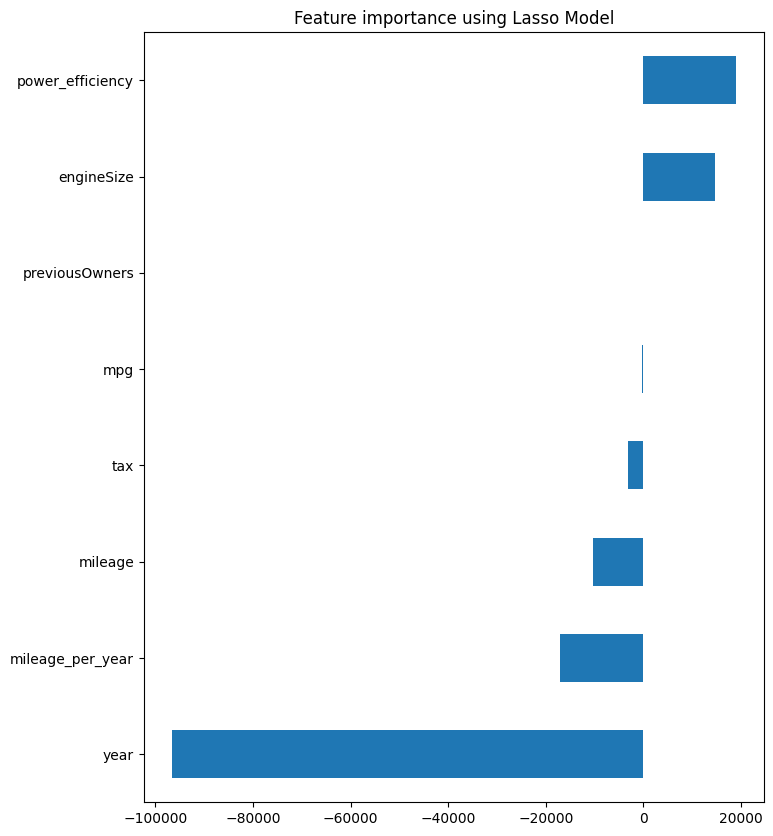

In [310]:
# CODE HERE
plot_importance(coef,'Lasso')


Numerical Data
| Feature            | Spearman | Mutual Info | RFE (LR) | Lasso | Decision     |
| ------------------ | -------- | ----------- | -------- | ----- | ------------ |
| **year**           | ✅        | ✅           | ✅        | ✅     | **Keep**     |
| **mileage**        | ❌        | ✅           | ✅        | ✅     | **Try (colinear with mileage per year)**     |
| **tax**            | ✅        | ❌           | ❌        | ❌     | Try          |
| **mpg**            | ❌        | ✅           | ❌        | ❌     | Try    |
| **engineSize**     | ❌       | ✅           | ✅         | ✅     | **Try (colinear with power_efficiency)**     |
| **paintQuality%**  | ❌        | ❌           | ❌        | ❌     | Discard      |
| **previousOwners** | ❌        | ❌           | ❌        | ❌     | Discard      |
| **mileage_per_year** | ✅         | ❌           | ✅        | ✅      | **Keep**      |
| **power_efficiency** | ❌         | ✅            | ✅        | ✅     | **Keep**      |

Categorical Data
| Feature          | Chi-Square | Cramér’s V | ANOVA F-test | Decision |
| ---------------- | ---------- | ---------- | ------------ | -------- |
| **brand**        | ✅          | ✅          | ✅            | **Keep** |
| **model**        | ✅          | ✅          | ✅            | **Keep** |
| **transmission** | ✅          | ✅          | ✅            | **Keep** |
| **fuelType**     | ❌          | ✅          | ✅            | Discard  |

Conclusion:

The most predictive features for our car price model appear to be:

Numerical: year, engineSize, mileage_per_year, power_efficiency <br>
Categorical: brand, model_specific and family, transmission
